In [1]:
#!/usr/bin/env python3
"""
Subsampling stability analysis for three motifs (TwINFER 3-gene sims)

For each motif CSV:

  1. Build a twin-aligned table with columns

         replicate, clone_id, X_t1, Y_t1, X_t2, Y_t2

     where:
         X = gene_2_mRNA, Y = gene_3_mRNA,
         t1 row comes from time_step = T1,
         t2 row comes from time_step = T2,
         and only clones that exist at BOTH times are kept.

     Conceptually: at t1 we “measure one twin”, at t2 we “measure the other twin”
     of the same family (same clone_id within a replicate).

     
  2. For each group size G in GROUP_SIZES:

       - Randomly shuffle these twin pairs and partition into disjoint
         groups of size G.

       - For each group g:

            rho_pop(g) = Spearman( X_t2, Y_t2 )      # population at t2
            rho_XY(g)  = Spearman( X_t1, Y_t2 )      # cross X(t1) → Y(t2)
            rho_YX(g)  = Spearman( Y_t1, X_t2 )      # cross Y(t1) → X(t2)

            Δ1(g) = rho_XY(g) - rho_pop(g)
            Δ2(g) = rho_YX(g) - rho_pop(g)

       - Collect arrays over groups and compute:

            mean/std of rhos
            mean/std + percentile CI of Δ
            sign ratio
            paired t-test p
            Wilcoxon p
            Brunner–Munzel p

"""

'\nSubsampling stability analysis for three motifs (TwINFER 3-gene sims)\n\nFor each motif CSV:\n\n  1. Build a twin-aligned table with columns\n\n         replicate, clone_id, X_t1, Y_t1, X_t2, Y_t2\n\n     where:\n         X = gene_2_mRNA, Y = gene_3_mRNA,\n         t1 row comes from time_step = T1,\n         t2 row comes from time_step = T2,\n         and only clones that exist at BOTH times are kept.\n\n     Conceptually: at t1 we “measure one twin”, at t2 we “measure the other twin”\n     of the same family (same clone_id within a replicate).\n\n\n  2. For each group size G in GROUP_SIZES:\n\n       - Randomly shuffle these twin pairs and partition into disjoint\n         groups of size G.\n\n       - For each group g:\n\n            rho_pop(g) = Spearman( X_t2, Y_t2 )      # population at t2\n            rho_XY(g)  = Spearman( X_t1, Y_t2 )      # cross X(t1) → Y(t2)\n            rho_YX(g)  = Spearman( Y_t1, X_t2 )      # cross Y(t1) → X(t2)\n\n            Δ1(g) = rho_XY(g) - rho_

In [2]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, ttest_rel, wilcoxon, binomtest, brunnermunzel

# ============================================================
# Config
# ============================================================

# Time points for the cross
T1 = 1*60
T2 = 20*60

# Target number of twin pairs (set to None to use all)
N_PAIRS_TARGET = 3000

# Group sizes (number of twin pairs per subsample)
num_pairs_per_group = [5] #np.arange(3, 20)

In [29]:
# Map motif name → CSV path
FILES = {
    # "Fan_out": (
    #     "/home/gzu5140/TwINFER-main 3/Simulation data/"
    #     "df_rows_0_1_2_07112025_203629_ncells_6000_Fan_out_median_0_0_8e8d08aa.csv"
    # ),
    # "Feed_forward": (
    #     "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/three_gene_sim/"
    #     "df_rows_0_1_2_11112025_102641_ncells_6000_Feed_forward_1_0_1_1_1_2_1_3_1_4_1_5_1_6_1_7_1_8_1_9_b4e19d9d.csv"
    # ),
    "Mutual_regulation": (
        "/home/gzu5140/Keerthana_b1042/grnInference/simulationData/fixed_time_step/"
        "simulation_matrix101_parameter_sheet101.csv"
    ),
}

# Column names in the CSVs
TIME_COL = "timestep"
ID_COLS = ["clone_id", "replicate"]

# X/Y gene columns (we care about X–Y correlation)
X_COL = "gene_2_total_mRNA"  # X
Y_COL = "gene_3_total_mRNA"  # Y


# ============================================================
# Helper: build twin-aligned table from full CSV
# ============================================================

def build_twin_table(
    df: pd.DataFrame,
    t1: int = T1,
    t2: int = T2,
    time_col: str = TIME_COL,
    id_cols=ID_COLS,
    x_col: str = X_COL,
    y_col: str = Y_COL,
    max_pairs: int | None = N_PAIRS_TARGET,
    random_state: int = 0,
) -> pd.DataFrame:
    """
    Build a twin-aligned table with columns:

        replicate, clone_id, X_t1, Y_t1, X_t2, Y_t2

    Definition of a "twin pair":

        same (replicate, clone_id) present at both time t1 and time t2.

    Implementation:

        1. Restrict to needed columns.
        2. Take the slice at t1 and rename to X_t1, Y_t1.
        3. Take the slice at t2 and rename to X_t2, Y_t2.
        4. Inner-merge on (replicate, clone_id).
        5. If there are more than `max_pairs` rows, sample exactly `max_pairs`.
    """
    rng = np.random.default_rng(random_state)

    keep_cols = list(id_cols) + [time_col, x_col, y_col]
    df = df[keep_cols].copy()
    
    # t1 slice
    df_t1 = (
        df[(df[time_col] == t1) & (df["replicate"] == 0)]
        .rename(columns={x_col: "X_t1", y_col: "Y_t1"})
        .drop(columns=[time_col])
    )
    print("df_t1")
    print(df_t1)
    # t2 slice
    df_t2 = (
        df[(df[time_col] == t2) & (df["replicate"] == 1)]
        .rename(columns={x_col: "X_t2", y_col: "Y_t2"})
        .drop(columns=[time_col])
    )
    print("df_t2")
    print(df_t2)
    # Merge on (replicate, clone_id) to keep true twins
    twin_tab = df_t1.merge(
        df_t2,
        on=['clone_id'],
        how="inner",
        validate="one_to_one",  # raises if duplicates are weird
    )
    print(twin_tab)
    # Just in case, group by id and average numeric columns
    twin_tab = (
        twin_tab
        .groupby(['clone_id'], as_index=False)
        .mean(numeric_only=True)
    )
    print(twin_tab)
    n_pairs = len(twin_tab)
    print(f"  [build_twin_table] Found {n_pairs} twin pairs before sampling.")

    if (max_pairs is not None) and (n_pairs > max_pairs):
        twin_tab = twin_tab.sample(
            n=max_pairs, random_state=random_state
        ).reset_index(drop=True)
        n_pairs = max_pairs
        print(f"  [build_twin_table] Downsampled to {n_pairs} twin pairs.")

    return twin_tab



# ============================================================
# Main
# ============================================================

if __name__ == "__main__":
    for motif, path in FILES.items():
        analyze_file(motif, path)


Motif: Mutual_regulation
File : /home/gzu5140/Keerthana_b1042/grnInference/simulationData/fixed_time_step/simulation_matrix101_parameter_sheet101.csv
--------------------------------------------------------------------------------
df_t1
       clone_id  replicate      X_t1      Y_t1
6000          0          0  2.333333  0.000000
6001          1          0  3.333333  0.000000
6002          2          0  2.666667  7.333333
6003          3          0  1.333333  0.000000
6004          4          0  0.000000  1.666667
...         ...        ...       ...       ...
11995      5995          0  2.666667  0.333333
11996      5996          0  0.000000  0.000000
11997      5997          0  0.000000  2.666667
11998      5998          0  0.000000  0.000000
11999      5999          0  0.000000  0.666667

[6000 rows x 4 columns]
df_t2
        clone_id  replicate       X_t2          Y_t2
408000         0          1   6.000000  2.010510e+01
408001         1          1   5.000000  3.609084e+00
408002   

In [43]:
mutual_regulation_sim = pd.read_csv("/home/gzu5140/Keerthana_b1042/grnInference/simulationData/fixed_time_step/simulation_matrix101_parameter_sheet101.csv")

In [47]:
mutual_regulation_sim[mutual_regulation_sim['replicate'] == 1]

,gene_1_is_bursting,gene_1_unspliced_mRNA,gene_1_spliced_mRNA,gene_1_protein,gene_1_k_on_adjusted,gene_1_total_mRNA,gene_1_mRNA_ever_produced,gene_1_protein_ever_produced,gene_2_is_bursting,gene_2_unspliced_mRNA,...,gene_3_spliced_mRNA,gene_3_protein,gene_3_k_on_adjusted,gene_3_total_mRNA,gene_3_mRNA_ever_produced,gene_3_protein_ever_produced,timestep,cell_id,replicate,clone_id
0,0.0,0.000000e+00,0.000000,214580.215794,0.66,0.000000,0.000000,0.000000,0.0,0.000000e+00,...,0.000000,5.410518e+05,0.66,0.000000,0.000000,0.000000,0,0,1,0
1,0.0,0.000000e+00,0.000000,767264.021606,0.66,0.000000,0.000000,0.000000,0.0,0.000000e+00,...,0.000000,1.153598e+06,0.66,0.000000,0.000000,0.000000,0,1,1,1
2,0.0,0.000000e+00,0.000000,377915.873775,0.66,0.000000,0.000000,0.000000,0.0,0.000000e+00,...,0.000000,6.857769e+05,0.66,0.000000,0.000000,0.000000,0,2,1,2
3,0.0,0.000000e+00,0.000000,595420.347035,0.66,0.000000,0.000000,0.000000,0.0,0.000000e+00,...,0.000000,8.795412e+05,0.66,0.000000,0.000000,0.000000,0,3,1,3
4,0.0,0.000000e+00,0.000000,585902.060238,0.66,0.000000,0.000000,0.000000,1.0,0.000000e+00,...,0.000000,9.578025e+05,0.66,0.000000,0.000000,0.000000,0,4,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
287995,0.0,9.120712e-06,4.666363,217759.145351,0.66,4.666373,76.000000,192210.441472,0.0,1.006424e-01,...,5.328504,6.514414e+05,0.66,5.354186,75.333333,230364.163129,2820,5995,1,5995
287996,0.0,4.085281e-06,8.192505,358226.213505,0.66,8.192509,100.333333,301842.116879,0.0,1.921167e-10,...,10.237557,3.592028e+05,0.66,10.237557,82.666667,194780.469567,2820,5996,1,5996
287997,0.0,1.128777e-01,8.220584,405994.298822,0.66,8.333461,67.333333,154367.543835,0.0,1.206441e-05,...,10.311317,5.193641e+05,0.66,11.126030,96.000000,206890.878771,2820,5997,1,5997
287998,0.0,2.100598e-06,4.741258,204955.941392,0.66,4.741260,43.000000,113126.391715,0.0,5.410203e-01,...,14.505553,1.908991e+05,0.66,14.517902,85.000000,237695.244938,2820,5998,1,5998


## Plot correlation and cross_correlation across time

In [5]:
t1_fixed = 1*60
t2_values = list(range(1*60, 48*60,60))   # 1..48
time_col = 'timestep'

# Default twin definition (can be overridden; auto-detect per file anyway)
rep_t1 = 1   # twin A (at t1)
rep_t2 = 2   # twin B (at t2)

# Gene columns (Z, X, Y)
y_col  = 'gene_1_total_mRNA'  # Z
x1_col = 'gene_2_total_mRNA'  # X
x2_col = 'gene_3_total_mRNA'  # Y
# Label the genes as Z, X, Y (for legend text)
GENE_LABELS = {
    y_col:  "Z",   # gene_1_mRNA
    x1_col: "X",   # gene_2_mRNA
    x2_col: "Y",   # gene_3_mRNA
}

# Pair order (undirected pairs) and labels:
#   X-Y, Z-Y, Z-X
PAIR_ORDER  = [
    (x1_col, x2_col),   # X-Y
    (y_col,  x2_col),   # Z-Y
    (y_col,  x1_col),   # Z-X
]
PAIR_LABELS = {(a, b): f"{GENE_LABELS[a]}-{GENE_LABELS[b]}" for (a, b) in PAIR_ORDER}
METRICS_TO_PLOT = ["Spearman(x_t1,y_t2)", "Spearman(y_t1,x_t2)"]
# Colors
COL_ZX = "#3E8ED0"
COL_ZY = "#F5B700"
COL_XY = "#D73027"
COL_YX = "#00A676"

In [6]:
def spearman_cross_twins_per_file_like_matrix(
    filepath,
    t1,
    t2,
    time_col=time_col,
    y_col=y_col,
    x1_col=x1_col,
    x2_col=x2_col,
    rep_t1=None,
    rep_t2=None,
    type_comparison="twin",  # "twin" or "random"
) -> pd.DataFrame:
    """
    Compute cross-time Spearman correlations using *half* the clones as real twins:

      - Conceptually: 1/4 clones sampled both twins at t1,
                      1/4 clones sampled both twins at t2,
                      1/2 clones sampled TwinA at t1, TwinB at t2 (used for cross).

      - In code: after aligning twins by clone_id, we randomly keep exactly half
        of the clones to mimic that 1/2 fraction used for cross.

    For each undirected gene pair (g1, g2) in PAIR_ORDER, we return:
      - Spearman(x_t1,y_t2): g1(t1, A) vs g2(t2, B)
      - Spearman(y_t1,x_t2): g2(t1, A) vs g1(t2, B)

    If type_comparison == "random", we break the twin pairing by
    randomly permuting the t2 rows *within* that half-sampled set.
    """
    df = pd.read_csv(filepath)

    # --- decide which replicate labels are twin A / twin B for THIS file ---
    if rep_t1 is None or rep_t2 is None:
        repA, repB = detect_twins_scheme(df)
    else:
        repA, repB = rep_t1, rep_t2

    base_cols = ["clone_id", "replicate", y_col, x1_col, x2_col]

    # ---------- slice twin A at t1, twin B at t2 ----------
    df_t1 = df.loc[
        (df[time_col] == t1) & (df["replicate"] == repA),
        base_cols
    ].copy()
    df_t2 = df.loc[
        (df[time_col] == t2) & (df["replicate"] == repB),
        base_cols
    ].copy()

    # If there are multiple rows per clone at a given time/rep, average them
    if df_t1.duplicated(subset=["clone_id"]).any():
        df_t1 = df_t1.groupby("clone_id", as_index=False).mean(numeric_only=True)
    if df_t2.duplicated(subset=["clone_id"]).any():
        df_t2 = df_t2.groupby("clone_id", as_index=False).mean(numeric_only=True)

    # ---------- strict twin safety check on clone_id sets ----------
    clones_t1 = set(df_t1["clone_id"])
    clones_t2 = set(df_t2["clone_id"])

    if type_comparison == "twin":
        if clones_t1 != clones_t2:
            only_t1 = sorted(clones_t1 - clones_t2)
            only_t2 = sorted(clones_t2 - clones_t1)
            print("[error] Twin mismatch between t1 and t2 for file:", filepath)
            print(f"  t1 {t1} (rep={repA}) clones: {len(clones_t1)}")
            print(f"  t2 {t2} (rep={repB}) clones: {len(clones_t2)}")
            if only_t1:
                print("  present only at t1 {t1} (first few):", only_t1[:10])
            if only_t2:
                print(f"  present only at t2 {t2} (first few):", only_t2[:10])
            raise ValueError("Mismatch in clone_id sets between t1 and t2 for twin comparison")

    # Rename columns to tag t1 / t2 so we have both copies in the merge
    rename_t1 = {col: f"{col}_t1" for col in [y_col, x1_col, x2_col]}
    rename_t2 = {col: f"{col}_t2" for col in [y_col, x1_col, x2_col]}

    df_t1 = df_t1.rename(columns=rename_t1)
    df_t2 = df_t2.rename(columns=rename_t2)

    # ---------- align twins by clone_id ----------
    merged = df_t1.merge(df_t2, on="clone_id", how="inner")

    if merged.empty:
        cols = ["gene_pair", "Spearman(x_t1,y_t2)", "Spearman(y_t1,x_t2)"]
        return pd.DataFrame(columns=cols).set_index("gene_pair")

    # ---------- HALF-sampling of clones for cross-twin pairs ----------
    n_total = len(merged)
    if n_total >= 2:
        n_keep = n_total // 2  # floor, half the clones
        idx = np.random.permutation(n_total)[:n_keep]
        merged = merged.iloc[idx].reset_index(drop=True)
    # if n_total < 2, keep as is

    # ---------- random comparison: break twin pairing within kept clones ----------
    if type_comparison == "random":
        n = len(merged)
        perm = np.random.permutation(n)
        merged_rand = merged.copy()
        for col in [f"{y_col}_t2", f"{x1_col}_t2", f"{x2_col}_t2"]:
            merged_rand[col] = merged[col].values[perm]
        used_df = merged_rand
    else:
        used_df = merged

    # ---------- compute directional Spearman ----------
    rows = []
    for (g1, g2) in PAIR_ORDER:
        # forward: g1(t1, A) → g2(t2, B)
        x_forward = used_df[f"{g1}_t1"].values
        y_forward = used_df[f"{g2}_t2"].values
        r_forward = _spearman(x_forward, y_forward)

        # reverse: g2(t1, A) → g1(t2, B)
        x_reverse = used_df[f"{g2}_t1"].values
        y_reverse = used_df[f"{g1}_t2"].values
        r_reverse = _spearman(x_reverse, y_reverse)

        rows.append({
            "gene_pair": PAIR_LABELS[(g1, g2)],  # "X-Y", "Z-Y", "Z-X"
            "Spearman(x_t1,y_t2)": r_forward,
            "Spearman(y_t1,x_t2)": r_reverse,
        })

    return pd.DataFrame(rows).set_index("gene_pair")

In [7]:
def detect_twins_scheme(df: pd.DataFrame):
    """
    Decide which replicate labels are twin A and twin B for this file.

    - If replicates include 0 and 1  -> A = 0, B = 1
    - Else if replicates include 1 and 2 (and no 0) -> A = 1, B = 2
    - Otherwise, raise an error.
    """
    reps = set(df["replicate"].dropna().unique())

    if {0, 1}.issubset(reps):
        return 0, 1   # twin A, twin B
    elif {1, 2}.issubset(reps) and 0 not in reps:
        return 1, 2   # twin A, twin B
    else:
        raise ValueError(f"Cannot infer twin scheme from replicates: {sorted(reps)}")

def _spearman(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return np.nan
    r, _ = spearmanr(a[m], b[m])
    return float(r)

def detect_twins(df):
    reps = set(df["replicate"].unique())
    if {0,1}.issubset(reps):
        return 0,1
    elif {1,2}.issubset(reps) and 0 not in reps:
        return 1,2
    else:
        raise ValueError("Cannot detect twin labels")

def load_twins(path):
    df = pd.read_csv(path)
    repA, repB = detect_twins(df)

    cols = ["clone_id", y_col, x1_col, x2_col]

    d1 = df[(df[time_col] == t1) & (df["replicate"] == repA)][cols].copy()
    d2 = df[(df[time_col] == t2) & (df["replicate"] == repB)][cols].copy()

    if d1.duplicated("clone_id").any():
        d1 = d1.groupby("clone_id", as_index=False).mean()
    if d2.duplicated("clone_id").any():
        d2 = d2.groupby("clone_id", as_index=False).mean()

    m = d1.merge(d2, on="clone_id", suffixes=("_t1","_t2"))
    Z1 = m[f"{y_col}_t1"].values
    X1 = m[f"{x1_col}_t1"].values
    Y1 = m[f"{x2_col}_t1"].values
    X2 = m[f"{x1_col}_t2"].values
    Y2 = m[f"{x2_col}_t2"].values
    return Z1, X1, Y1, X2, Y2

In [3]:


# ============================================================
# Subsampling into groups and computing rhos
# ============================================================

def subsample_groups(
    twin_tab: pd.DataFrame,
    n_groups: int,
    random_state: int = 0,
):
    """
    Partition twin pairs into disjoint groups of size `group_size`.

    Each row of `twin_tab` is one twin pair with:
        X_t1, Y_t1, X_t2, Y_t2.

    For each group g, compute:

        rho_pop(g) = Spearman( X_t2, Y_t2 )      # population at t2
        rho_XY(g)  = Spearman( X_t1, Y_t2 )      # X_t1 → Y_t2
        rho_YX(g)  = Spearman( Y_t1, X_t2 )      # Y_t1 → X_t2

    Returns:
        rho_pop_arr, rho_XY_arr, rho_YX_arr, n_groups, pairs_per_group
        or (None, None, None, 0, 0) if not enough clones.
    """
    rng = np.random.default_rng(random_state)

    twin_tab = twin_tab.reset_index(drop=True)
    n_total = len(twin_tab)

    group_size = n_total // n_groups
    if n_total < group_size:
        return None, None, None, 0, 0

    idx = np.arange(n_total)
    rng.shuffle(idx)
    
    if n_groups < 1:
        return None, None, None, 0, 0

    idx = idx[: n_groups * group_size]
    idx_groups = np.array_split(idx, n_groups)

    rho_pop_list = []
    rho_XY_list = []
    rho_YX_list = []

    for g_idx in idx_groups:
        g = twin_tab.iloc[g_idx]

        if len(g) < 5:
            # too small to compute stable Spearman
            continue
        # Population: same-time correlation at t2
        r_pop, _ = spearmanr(g["X_t2"].to_numpy(),
                             g["Y_t2"].to_numpy())

        # Cross X_t1 → Y_t2
        r_XY, _ = spearmanr(g["X_t1"].to_numpy(),
                            g["Y_t2"].to_numpy())

        # Cross Y_t1 → X_t2
        r_YX, _ = spearmanr(g["Y_t1"].to_numpy(),
                            g["X_t2"].to_numpy())

        rho_pop_list.append(r_pop)
        rho_XY_list.append(r_XY)
        rho_YX_list.append(r_YX)

    if len(rho_pop_list) == 0:
        return None, None, None, 0, 0

    return (np.array(rho_pop_list),
            np.array(rho_XY_list),
            np.array(rho_YX_list),
            len(rho_pop_list),
            group_size)


# ============================================================
# Summary stats + tests (including Brunner–Munzel)
# ============================================================

def stability_summary(
    rho_pop: np.ndarray,
    rho_XY: np.ndarray,
    rho_YX: np.ndarray,
) -> dict:
    """
    Given arrays of rho_pop, rho_XY, rho_YX (same length),
    compute summary statistics & tests for:

        Δ1 = rho_XY - rho_pop
        Δ2 = rho_YX - rho_pop
    """
    n_groups = len(rho_pop)

    result = {
        "n_groups": n_groups,
        "mean_rho_pop": np.nan,
        "std_rho_pop": np.nan,
        "mean_rho_XY": np.nan,
        "std_rho_XY": np.nan,
        "mean_rho_YX": np.nan,
        "std_rho_YX": np.nan,
        "delta1_mean": np.nan,
        "delta1_std": np.nan,
        "delta1_ci_low": np.nan,
        "delta1_ci_high": np.nan,
        "delta2_mean": np.nan,
        "delta2_std": np.nan,
        "delta2_ci_low": np.nan,
        "delta2_ci_high": np.nan,
        "sign_ratio_d1": np.nan,
        "sign_ratio_d2": np.nan,
        "ttest_p_d1": np.nan,
        "ttest_p_d2": np.nan,
        "wilcoxon_p_d1": np.nan,
        "wilcoxon_p_d2": np.nan,
        "sign_test_p_d1": np.nan,
        "sign_test_p_d2": np.nan
    }

    if n_groups == 0:
        return result

    d1 = rho_XY - rho_pop
    d2 = rho_YX - rho_pop

    # Means / stds
    result["mean_rho_pop"] = float(np.nanmean(rho_pop))
    result["std_rho_pop"] = float(np.nanstd(rho_pop, ddof=1))
    result["mean_rho_XY"] = float(np.nanmean(rho_XY))
    result["std_rho_XY"] = float(np.nanstd(rho_XY, ddof=1))
    result["mean_rho_YX"] = float(np.nanmean(rho_YX))
    result["std_rho_YX"] = float(np.nanstd(rho_YX, ddof=1))

    result["delta1_mean"] = float(np.nanmean(d1))
    result["delta1_std"] = float(np.nanstd(d1, ddof=1))
    result["delta2_mean"] = float(np.nanmean(d2))
    result["delta2_std"] = float(np.nanstd(d2, ddof=1))

    # Percentile CI
    ci1_low, ci1_high = np.percentile(d1, [2.5, 97.5])
    ci2_low, ci2_high = np.percentile(d2, [2.5, 97.5])
    result["delta1_ci_low"] = float(ci1_low)
    result["delta1_ci_high"] = float(ci1_high)
    result["delta2_ci_low"] = float(ci2_low)
    result["delta2_ci_high"] = float(ci2_high)

    # Sign ratios
    k_pos1 = np.sum(d1 > 0)
    k_pos2 = np.sum(d2 > 0)
    result["sign_ratio_d1"] = float(k_pos1 / n_groups)
    result["sign_ratio_d2"] = float(k_pos2 / n_groups)

    # Paired t-test
    if n_groups >= 2:
        try:
            _, p1 = ttest_rel(rho_XY, rho_pop)
        except Exception:
            p1 = np.nan
        try:
            _, p2 = ttest_rel(rho_YX, rho_pop)
        except Exception:
            p2 = np.nan
        result["ttest_p_d1"] = float(p1)
        result["ttest_p_d2"] = float(p2)

    # Wilcoxon
    if n_groups >= 3:
        try:
            _, pw1 = wilcoxon(rho_XY, rho_pop, alternative="two-sided")
        except Exception:
            pw1 = np.nan
        try:
            _, pw2 = wilcoxon(rho_YX, rho_pop, alternative="two-sided")
        except Exception:
            pw2 = np.nan
        result["wilcoxon_p_d1"] = float(pw1)
        result["wilcoxon_p_d2"] = float(pw2)

    # Sign test
    try:
        ps1 = binomtest(k_pos1, n_groups, 0.5, alternative="two-sided").pvalue
    except Exception:
        ps1 = np.nan
    try:
        ps2 = binomtest(k_pos2, n_groups, 0.5, alternative="two-sided").pvalue
    except Exception:
        ps2 = np.nan
    result["sign_test_p_d1"] = float(ps1)
    result["sign_test_p_d2"] = float(ps2)

    # Brunner–Munzel (treat as two samples; ignores pairing)
    _, bm_p1 = brunnermunzel(rho_XY, rho_pop, alternative="two-sided", )
    _, bm_p2 = brunnermunzel(rho_YX, rho_pop, alternative="two-sided")
    result["bm_p_d1"] = float(bm_p1)
    result["bm_p_d2"] = float(bm_p2)

    return result


# ============================================================
# Per-motif analysis
# ============================================================

def analyze_file(motif_name: str, path: str):
    print("=" * 80)
    print(f"Motif: {motif_name}")
    print(f"File : {path}")
    print("-" * 80)

    df = pd.read_csv(path)
   # 1) Build twin table (same clone at t1 and t2)
    twin_tab = build_twin_table(
        df,
        t1=T1,
        t2=T2,
        time_col=TIME_COL,
        id_cols=ID_COLS,
        x_col=X_COL,
        y_col=Y_COL,
        max_pairs=N_PAIRS_TARGET,
        random_state=0,
    )

    n_pairs = len(twin_tab)
    print(f"Total twin pairs used: {n_pairs}")

    rows_XY = []
    rows_YX = []

    for num_groups in num_pairs_per_group:
        rho_pop, rho_XY, rho_YX, n_groups, pairs_per_group = subsample_groups(
            twin_tab, n_groups=num_groups, random_state=0
        )

        if rho_pop is None:
            # invalid row for both tables
            row_XY = {
                "pairs_per_group": 0,
                "n_groups": 0,
                "mean_rho_pop": np.nan,
                "std_rho_pop": np.nan,
                "mean_crossXY": np.nan,
                "std_crossXY": np.nan,
                "delta_mean": np.nan,
                "delta_std": np.nan,
                "delta_ci_low": np.nan,
                "delta_ci_high": np.nan,
                "ttest_p": np.nan,
                "wilcoxon_p": np.nan,
                "bm_p": np.nan,
            }
            row_YX = {
                "pairs_per_group": 0,
                "n_groups": 0,
                "mean_rho_pop": np.nan,
                "std_rho_pop": np.nan,
                "mean_crossYX": np.nan,
                "std_crossYX": np.nan,
                "delta_mean": np.nan,
                "delta_std": np.nan,
                "delta_ci_low": np.nan,
                "delta_ci_high": np.nan,
                "ttest_p": np.nan,
                "wilcoxon_p": np.nan,
                "bm_p": np.nan,
            }
            rows_XY.append(row_XY)
            rows_YX.append(row_YX)
            continue

        summary = stability_summary(rho_pop, rho_XY, rho_YX)

        # X→Y row
        row_XY = {
            "pairs_per_group": pairs_per_group,
            "n_groups": summary["n_groups"],
            "mean_rho_pop": summary["mean_rho_pop"],
            "std_rho_pop": summary["std_rho_pop"],
            "mean_crossXY": summary["mean_rho_XY"],
            "std_crossXY": summary["std_rho_XY"],
            "delta_mean": summary["delta1_mean"],
            "delta_std": summary["delta1_std"],
            "delta_ci_low": summary["delta1_ci_low"],
            "delta_ci_high": summary["delta1_ci_high"],
            "ttest_p": summary["ttest_p_d1"],
            "wilcoxon_p": summary["wilcoxon_p_d1"],
            "bm_p": summary["bm_p_d1"],
        }
        rows_XY.append(row_XY)

        # Y→X row
        row_YX = {
            "pairs_per_group": pairs_per_group,
            "n_groups": summary["n_groups"],
            "mean_rho_pop": summary["mean_rho_pop"],
            "std_rho_pop": summary["std_rho_pop"],
            "mean_crossYX": summary["mean_rho_YX"],
            "std_crossYX": summary["std_rho_YX"],
            "delta_mean": summary["delta2_mean"],
            "delta_std": summary["delta2_std"],
            "delta_ci_low": summary["delta2_ci_low"],
            "delta_ci_high": summary["delta2_ci_high"],
            "ttest_p": summary["ttest_p_d2"],
            "wilcoxon_p": summary["wilcoxon_p_d2"],
            "bm_p": summary["bm_p_d2"],
        }
        rows_YX.append(row_YX)

    df_XY = pd.DataFrame(rows_XY)
    df_YX = pd.DataFrame(rows_YX)

    cols_XY = [
        "pairs_per_group", "n_groups",
        "mean_rho_pop", "std_rho_pop",
        "mean_crossXY", "std_crossXY",
        "delta_mean", "delta_std", "delta_ci_low", "delta_ci_high",
        "ttest_p", "wilcoxon_p", "bm_p",
    ]
    cols_YX = [
        "pairs_per_group", "n_groups",
        "mean_rho_pop", "std_rho_pop",
        "mean_crossYX", "std_crossYX",
        "delta_mean", "delta_std", "delta_ci_low", "delta_ci_high",
        "ttest_p", "wilcoxon_p", "bm_p",
    ]

    df_XY = df_XY[cols_XY]
    df_YX = df_YX[cols_YX]

    print("\n--- X→Y vs population ---")
    print(df_XY.to_string(index=False))
    print("\n--- Y→X vs population ---")
    print(df_YX.to_string(index=False))
    print()

    out_XY = f"subsample_stability_{motif_name}_XY.csv"
    out_YX = f"subsample_stability_{motif_name}_YX.csv"
    df_XY.to_csv(out_XY, index=False)
    df_YX.to_csv(out_YX, index=False)
    print(f"Saved X→Y table to: {out_XY}")
    print(f"Saved Y→X table to: {out_YX}\n")

In [8]:
import os
fp = "/home/gzu5140/Keerthana_b1042/grnInference/simulationData/fixed_time_step/fan_out.csv"
base = os.path.basename(fp)
records = []
t1 = t1_fixed
for t2 in t2_values:
    try:
        tbl = spearman_cross_twins_per_file_like_matrix(
                    fp, t1, t2,
                    time_col=time_col,
                    y_col=y_col,
                    x1_col=x1_col,
                    x2_col=x2_col,
                    # rep_t1 / rep_t2 left as None → auto-detect 0/1 vs 1/2
                    type_comparison="twin",
                )
    except Exception as e:
                
                print(f"[warn] {motif_name} | {base} | t2={t2}: {e}")
                continue

    for gp, row in tbl.iterrows():
        for metric in METRICS_TO_PLOT:
                    val = row.get(metric, np.nan)
                    records.append({
                        "motif":     "fan_out",
                        "file":      base,
                        "t1":        int(t1),
                        "t2":        int(t2),
                        "gene_pair": gp,
                        "metric":    metric,
                        "value":     None if pd.isna(val) else float(val),
                    })

In [ ]:
tidy_reg = pd.DataFrame(records)
tidy_reg

import matplotlib.pyplot as plt

metrics = ["Spearman(x_t1,y_t2)"]# tidy_reg['metric'].unique()
gene_pairs = tidy_reg['gene_pair'].unique()

fig, ax = plt.subplots(figsize=(8, 5))

for metric in metrics:
    for gp in gene_pairs:
        
        subset = tidy_reg[
            (tidy_reg["gene_pair"] == gp) &
            (tidy_reg["metric"] == metric)
        ]
        
        # Label: "X-Y · mse"
        label = f"{gp} · {metric}"
        
        ax.plot(
            subset["t2"]/60, 
            subset["value"], 
            label=label
        )

ax.set_xlabel("Time")
ax.set_ylabel("Metric value")

ax.legend(
    title="Fan Out Gene pair · Metric",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


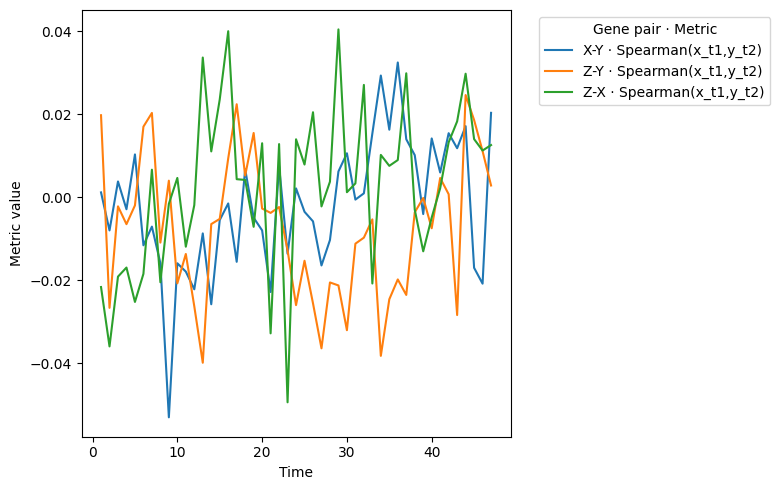

In [15]:
import matplotlib.pyplot as plt

metrics = ["Spearman(x_t1,y_t2)"]# tidy_reg['metric'].unique()
gene_pairs = tidy_reg['gene_pair'].unique()

fig, ax = plt.subplots(figsize=(8, 5))

for metric in metrics:
    for gp in gene_pairs:
        
        subset = tidy_reg[
            (tidy_reg["gene_pair"] == gp) &
            (tidy_reg["metric"] == metric)
        ]
        
        # Label: "X-Y · mse"
        label = f"{gp} · {metric}"
        
        ax.plot(
            subset["t2"]/60, 
            subset["value"], 
            label=label
        )

ax.set_xlabel("Time")
ax.set_ylabel("Metric value")

ax.legend(
    title="Gene pair · Metric",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()
